In [19]:
# STOCK PRICE TREND PREDICTION - S&P 500

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv(r'all_stocks_5yr.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Clean and Preprocess Data

# Parse dates
df['date'] = pd.to_datetime(df['date'])

# Handle missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Remove duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Add useful features
df['daily_return'] = (df['close'] - df['open']) / df['open'] * 100   # % daily return
df['price_range']  = df['high'] - df['low']                          # daily price range
df['target']       = (df['close'] > df['open']).astype(int)          # 1=price went UP, 0=DOWN

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of companies: {df['Name'].nunique()}")

Dataset Shape: (619040, 7)

First 5 rows:
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL

Missing values before cleaning:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

Missing values after cleaning:
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

Duplicate rows: 0

Cleaned dataset shape: (619029, 10)
Date range: 2013-02-08 to 2018-02-07
Number of companies: 505


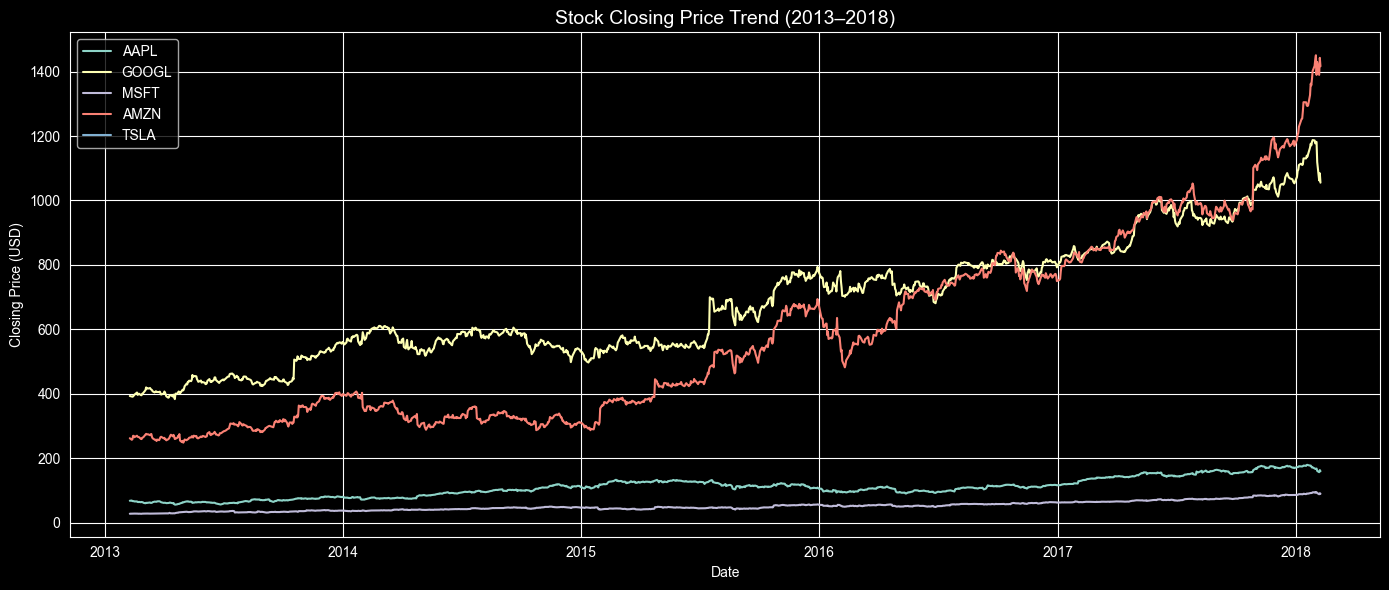

In [20]:
# Exploratory Data Analysis (EDA)
# Focus on 5 well-known stocks
top_stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
df_top = df[df['Name'].isin(top_stocks)]

# Close price trend over time
plt.figure(figsize=(14, 6))
for stock in top_stocks:
    subset = df_top[df_top['Name'] == stock]
    plt.plot(subset['date'], subset['close'], label=stock)
plt.title('Stock Closing Price Trend (2013–2018)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

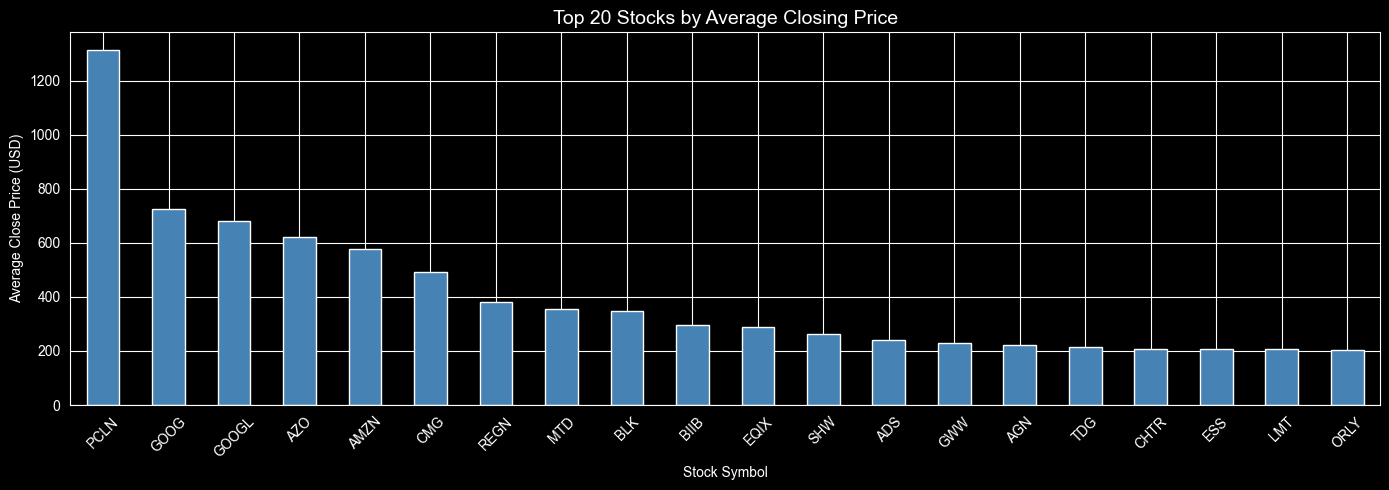

In [21]:
# Average closing price per company (top 20)
avg_close = df.groupby('Name')['close'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(14, 5))
avg_close.plot(kind='bar', color='steelblue')
plt.title('Top 20 Stocks by Average Closing Price', fontsize=14)
plt.xlabel('Stock Symbol')
plt.ylabel('Average Close Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

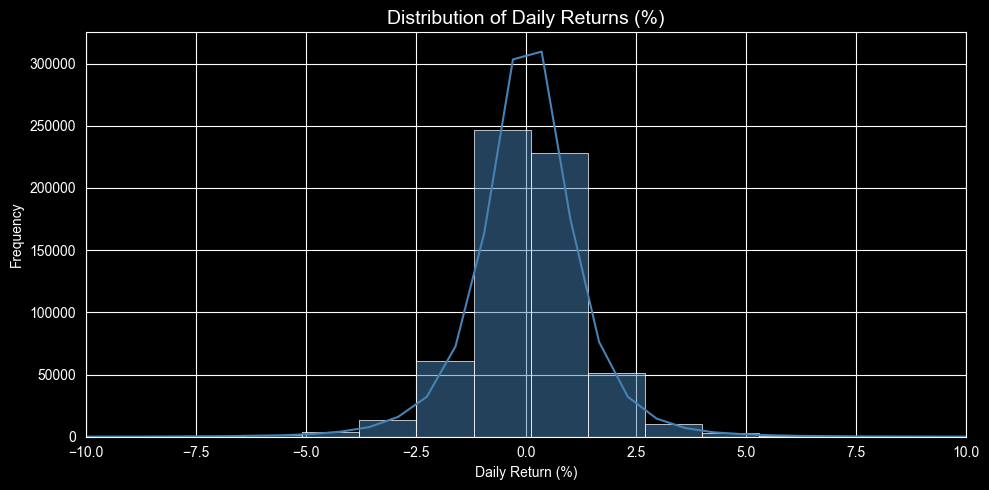

In [22]:
# Distribution of daily returns
plt.figure(figsize=(10, 5))
sns.histplot(df['daily_return'], bins=100, kde=True, color='steelblue')
plt.title('Distribution of Daily Returns (%)', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.xlim(-10, 10)
plt.tight_layout()
plt.show()

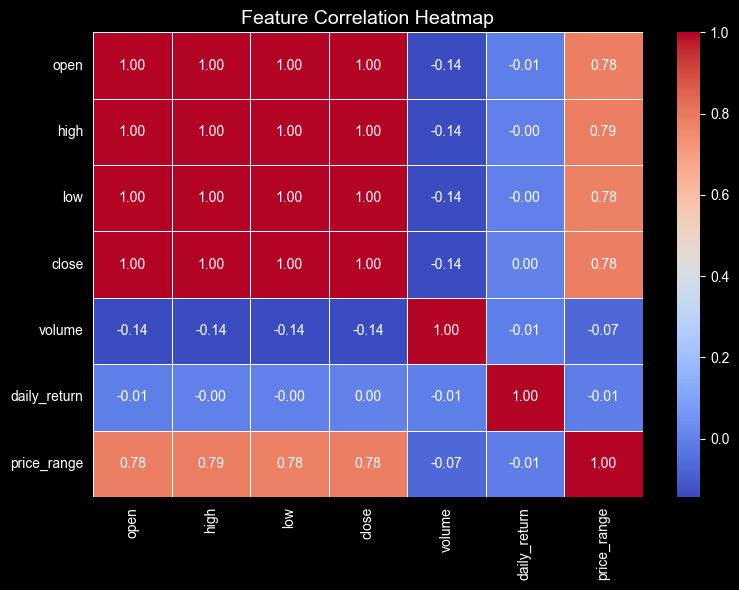

In [23]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_cols = ['open', 'high', 'low', 'close', 'volume', 'daily_return', 'price_range']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

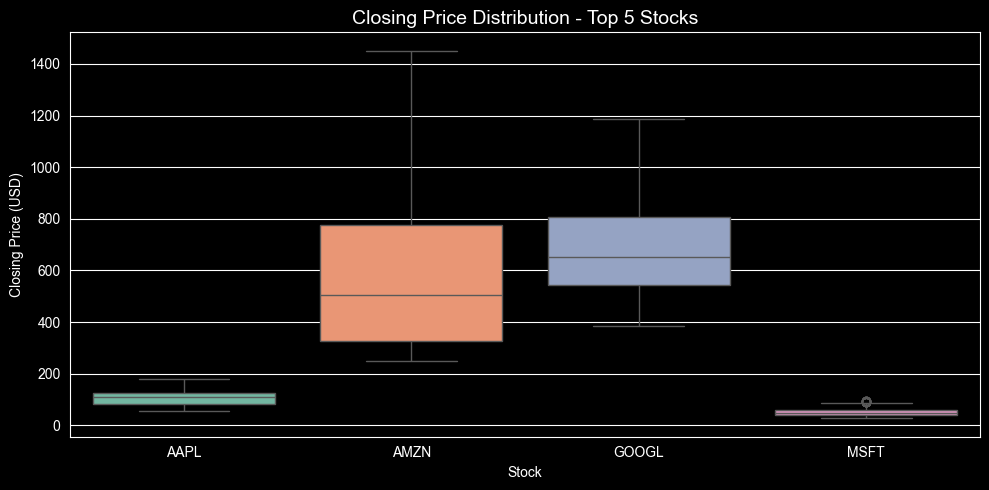

In [24]:
# Boxplot of closing prices for top 5 stocks
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_top, x='Name', y='close', palette='Set2')
plt.title('Closing Price Distribution - Top 5 Stocks', fontsize=14)
plt.xlabel('Stock')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.show()

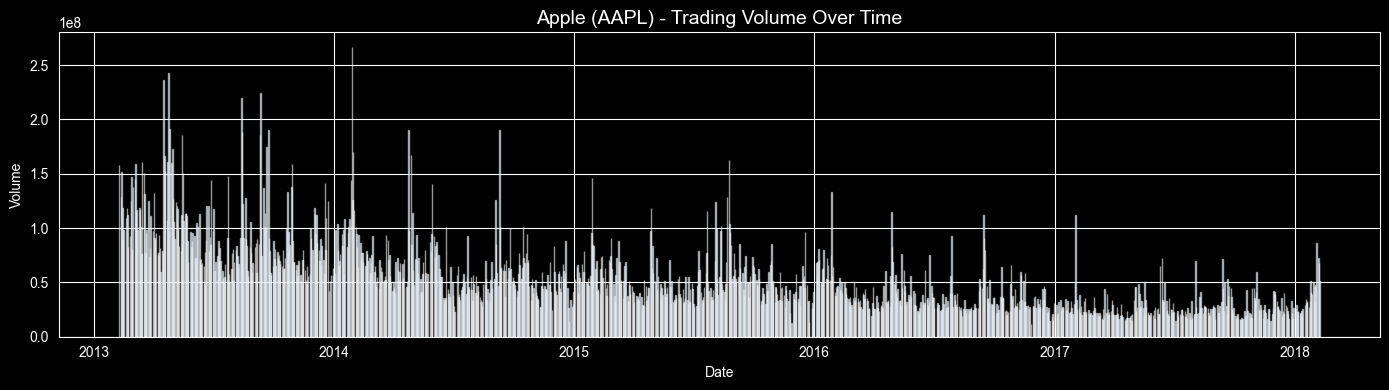

In [25]:
# Volume traded over time (AAPL)
aapl = df[df['Name'] == 'AAPL']
plt.figure(figsize=(14, 4))
plt.bar(aapl['date'], aapl['volume'], color='steelblue', alpha=0.6)
plt.title('Apple (AAPL) - Trading Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

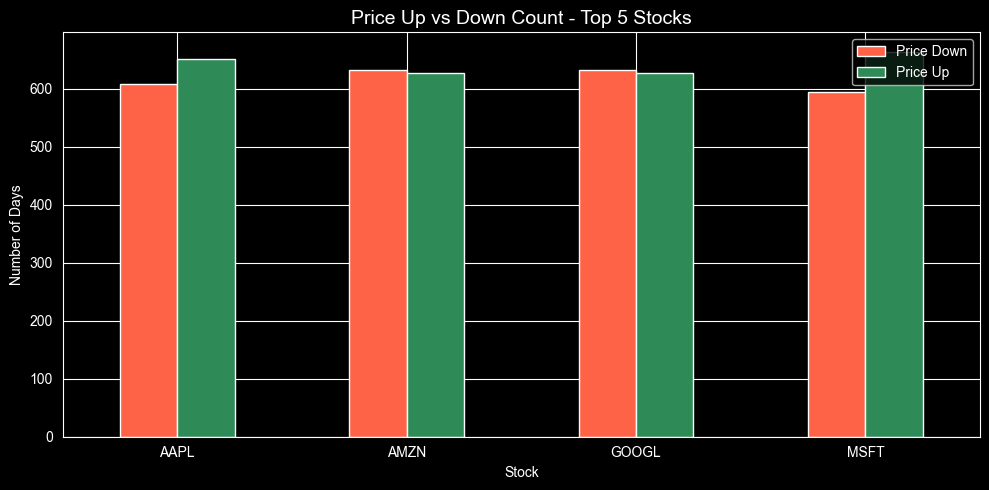

In [26]:
# Price Up vs Down per stock (top 5)
trend_counts = df_top.groupby(['Name', 'target']).size().unstack()
trend_counts.columns = ['Price Down', 'Price Up']
trend_counts.plot(kind='bar', figsize=(10, 5), color=['tomato', 'seagreen'])
plt.title('Price Up vs Down Count - Top 5 Stocks', fontsize=14)
plt.xlabel('Stock')
plt.ylabel('Number of Days')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


PCA - Proportion of Variance Explained:
PC1: 61.80%  |  Cumulative: 61.80%
PC2: 16.72%  |  Cumulative: 78.52%
PC3: 16.28%  |  Cumulative: 94.80%
PC4: 5.20%  |  Cumulative: 100.00%
PC5: 0.00%  |  Cumulative: 100.00%
PC6: 0.00%  |  Cumulative: 100.00%


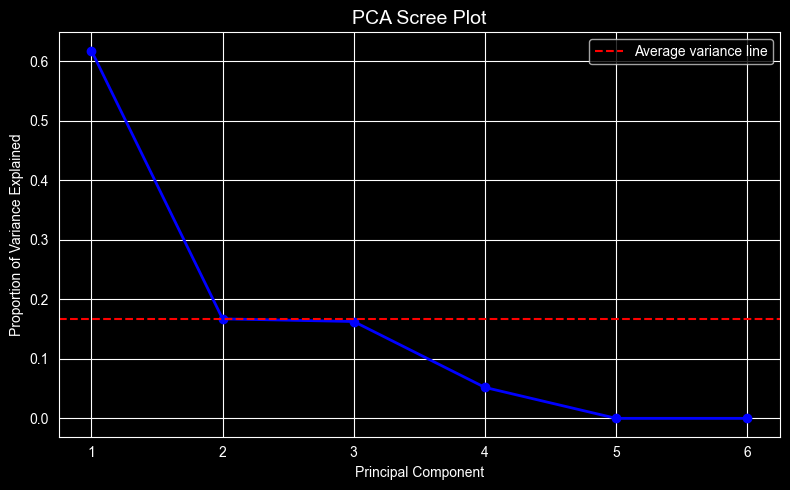

In [27]:
# PCA Analysis
feature_cols = ['open', 'high', 'low', 'volume', 'daily_return', 'price_range']
X_pca = df[feature_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("\nPCA - Proportion of Variance Explained:")
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {e*100:.2f}%  |  Cumulative: {c*100:.2f}%")

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained)+1), explained, 'bo-', linewidth=2)
plt.axhline(y=1/len(feature_cols), color='r', linestyle='--', label='Average variance line')
plt.title('PCA Scree Plot', fontsize=14)
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.legend()
plt.tight_layout()
plt.show()


Training samples: 881
Testing samples:  378

Linear Regression Performance:
  R² Score : 0.9999
  MAE      : 0.2010
  MSE      : 0.0846

Random Forest Performance:
  R² Score : 0.9995
  MAE      : 0.4702
  MSE      : 0.4803


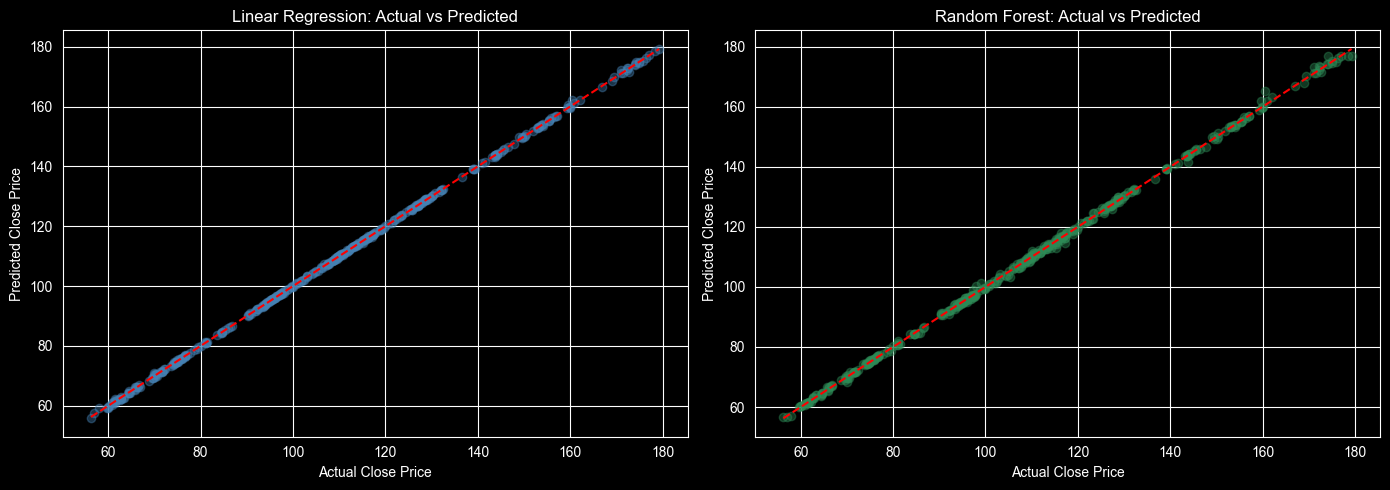

In [28]:
# ML Models - Predicting Closing Price
# Use AAPL for focused prediction
aapl = df[df['Name'] == 'AAPL'].copy()
aapl = aapl.sort_values('date')

# Features and target
features = ['open', 'high', 'low', 'volume', 'price_range', 'daily_return']
X = aapl[features]
y = aapl['close']

# Train/test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print("\nLinear Regression Performance:")
print(f"  R² Score : {lr_r2:.4f}")
print(f"  MAE      : {lr_mae:.4f}")
print(f"  MSE      : {lr_mse:.4f}")

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print("\nRandom Forest Performance:")
print(f"  R² Score : {rf_r2:.4f}")
print(f"  MAE      : {rf_mae:.4f}")
print(f"  MSE      : {rf_mse:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression: Actual vs Predicted', fontsize=12)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.4, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest: Actual vs Predicted', fontsize=12)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')

plt.tight_layout()
plt.show()

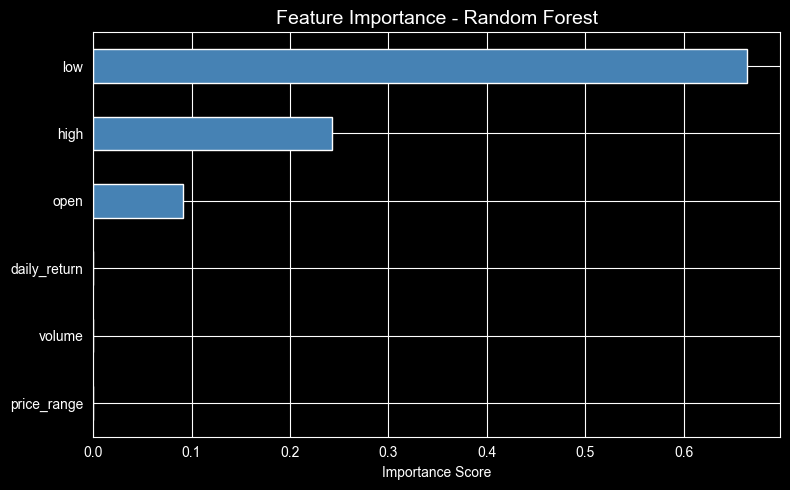

In [29]:
# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [30]:
# Model Comparison Summary
print("\n" + "="*55)
print("         MODEL PERFORMANCE COMPARISON SUMMARY")
print("="*55)
print(f"{'Metric':<15} {'Linear Regression':>18} {'Random Forest':>15}")
print("-"*55)
print(f"{'R² Score':<15} {lr_r2:>18.4f} {rf_r2:>15.4f}")
print(f"{'MAE':<15} {lr_mae:>18.4f} {rf_mae:>15.4f}")
print(f"{'MSE':<15} {lr_mse:>18.4f} {rf_mse:>15.4f}")
print("="*55)


         MODEL PERFORMANCE COMPARISON SUMMARY
Metric           Linear Regression   Random Forest
-------------------------------------------------------
R² Score                    0.9999          0.9995
MAE                         0.2010          0.4702
MSE                         0.0846          0.4803
